# Notebook 05 — Frequency Model
**Project: Coastal Property Catastrophe Loss Model**

Train an XGBoost binary classifier to predict **P(claim paid | property features)** — the probability a given property's filed claim results in a payment. This probability becomes the `RATE` column in our generated ELTs.

## Approach
- **Target:** Binary — claim paid (1) or not paid (0)
- **Class imbalance:** handled with `scale_pos_weight` (auto-computed, capped at 10)
- **Feature selection:** `FREQUENCY_FEATURES` — excludes leaky features (`log_storm_damage`, `coverage_to_value_ratio`)
- **Calibration:** Platt scaling on a **separate holdout** (3-way split avoids double-dipping)
- **Validation:** AUC-ROC, Average Precision, Brier Score, calibration curve, 5-fold CV
- **Output:** Calibrated probability in [0, 1] → ELT `RATE` column

## Base Rate Note
The training data consists of **NFIP claims records** — every row is a property that filed a claim.
The binary target `has_claim` = `(amountPaidOnBuildingClaim > 0)` distinguishes paid from unpaid claims.

**This means:** The model predicts *P(claim gets paid | claim was filed)*, **not** *P(property generates a claim in a given year)* for the general population. The ~77% positive rate reflects payment rates within the claims population, not annual claim frequency for all insured properties.

To obtain a true annual claim frequency for ELTs, this probability would need to be scaled by the filing rate (claims filed / policies in force). This is a known limitation documented here for transparency.

## Filing Rate Adjustment (handled in ELT Generator)
The `ELTGenerator` in notebook 06 applies this correction automatically:
```
annual_claim_rate = P(paid | filed) × P(filed | property-year)
                  = freq_model output × filing_rate
```
Filing rates are computed from OpenFEMA policy counts vs. claim counts, stratified by state and flood zone (see notebook 01, Section 7). This converts ~77% model outputs into realistic ~2–5% annual rates.

In [1]:
import sys
sys.path.insert(0, '../src')

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import warnings
warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

from frequency_model import FrequencyModel
from feature_engineering import FREQUENCY_FEATURES, SEVERITY_FEATURES

DATA_DIR  = Path('../data/raw')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

X_all = pd.read_parquet(DATA_DIR / 'features.parquet')
targets = pd.read_parquet(DATA_DIR / 'targets.parquet')
y_freq = targets['has_claim']

# Use FREQUENCY_FEATURES only (excludes leaky features: log_storm_damage, coverage_to_value_ratio)
X = X_all[FREQUENCY_FEATURES]

print(f'All features:       {X_all.shape[1]} cols (SEVERITY_FEATURES)')
print(f'Frequency features: {X.shape[1]} cols (leaky features removed)')
print(f'Removed:            {sorted(set(SEVERITY_FEATURES) - set(FREQUENCY_FEATURES))}')
print(f'Feature matrix:     {X.shape}')
print(f'Positive rate:      {y_freq.mean():.1%} ({y_freq.sum():,} of {len(y_freq):,})')
print(f'\nNote: {y_freq.mean():.0%} positive rate is expected — data is NFIP claims,')
print(f'      so target = P(paid | filed), not P(filed | property).')

All features:       20 cols (SEVERITY_FEATURES)
Frequency features: 18 cols (leaky features removed)
Removed:            ['coverage_to_value_ratio', 'log_storm_damage']
Feature matrix:     (336662, 18)
Positive rate:      76.9% (258,897 of 336,662)

Note: 77% positive rate is expected — data is NFIP claims,
      so target = P(paid | filed), not P(filed | property).


## 1. Train/Test Split

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_freq, test_size=0.2, stratify=y_freq, random_state=42
)
print(f'Train: {len(X_train):,} | pos rate: {y_train.mean():.1%}')
print(f'Test:  {len(X_test):,}  | pos rate: {y_test.mean():.1%}')

Train: 269,329 | pos rate: 76.9%
Test:  67,333  | pos rate: 76.9%


## 2. Cross-Validation (stability check)
Before training the final model, run 5-fold CV to confirm metrics are stable across folds.
This reveals whether the model generalizes or overfits to a particular split.

In [3]:
cv_model = FrequencyModel(
    params={
        'n_estimators': 1000,
        'max_depth': 5,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'early_stopping_rounds': 50,
    },
)

cv_results = cv_model.cross_validate(X_train, y_train, n_folds=5, verbose=True)

print('\n5-Fold Cross-Validation Results:')
print(cv_results.to_string(index=False))
print(f'\nAUC:   {cv_results["auc"].mean():.4f} +/- {cv_results["auc"].std():.4f}')
print(f'AP:    {cv_results["avg_precision"].mean():.4f} +/- {cv_results["avg_precision"].std():.4f}')
print(f'Brier: {cv_results["brier_score"].mean():.4f} +/- {cv_results["brier_score"].std():.4f}')

# Check stability
auc_cv = cv_results['auc'].std() / cv_results['auc'].mean()
print(f'\nAUC CV (std/mean): {auc_cv:.3f} — {"stable" if auc_cv < 0.05 else "UNSTABLE — investigate"}')

INFO:   Fold 1: AUC=0.7611, AP=0.9028


INFO:   Fold 2: AUC=0.7630, AP=0.9029


INFO:   Fold 3: AUC=0.7607, AP=0.9021


INFO:   Fold 4: AUC=0.7642, AP=0.9046


INFO:   Fold 5: AUC=0.7621, AP=0.9031


INFO: 
CV Summary: AUC=0.7622±0.0014, AP=0.9031±0.0009



5-Fold Cross-Validation Results:
 fold      auc  avg_precision  brier_score
    1 0.761093       0.902843     0.193438
    2 0.763002       0.902920     0.191993
    3 0.760698       0.902133     0.193387
    4 0.764237       0.904569     0.192371
    5 0.762128       0.903130     0.193445

AUC:   0.7622 +/- 0.0014
AP:    0.9031 +/- 0.0009
Brier: 0.1929 +/- 0.0007

AUC CV (std/mean): 0.002 — stable


## 3. Train Frequency Model
Uses a **3-way split** internally: train (70%) / eval for early stopping (15%) / calibration holdout (15%).
This avoids calibration double-dipping (fitting Platt scaling on the same data used for early stopping).

In [4]:
freq_model = FrequencyModel(
    params={
        'n_estimators': 1000,
        'max_depth': 5,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'early_stopping_rounds': 50,
    },
    calibrate=True,       # Apply Platt scaling on separate holdout
    max_pos_weight=10.0,  # Cap scale_pos_weight to prevent calibration distortion
)

freq_model.fit(X_train, y_train, verbose=True)

INFO: Training frequency model on 269,329 records | Positive rate: 76.9%


INFO: scale_pos_weight: 0.30


INFO: 3-way split: train=188,530 | eval=40,399 | cal=40,400


[0]	validation_0-auc:0.66186


[100]	validation_0-auc:0.72822


...

[400]	validation_0-auc:0.75535


[499]	validation_0-auc:0.75801


INFO: Pre-calibration: AUC=0.7580 | AP=0.9013 | Best iter=499


INFO: Applying Platt scaling on held-out calibration set...


INFO: Post-calibration: Brier=0.1444 (raw=0.1927) | AUC=0.7621


## 4. Evaluate on Test Set

INFO: Frequency evaluation | AUC=0.7619 | AP=0.9029 | Brier=0.1443


Test Set Performance:
  AUC-ROC:           0.7619
  Average Precision: 0.9029
  Brier Score:       0.1443  (lower = better calibration)
  Log Loss:          0.4522
  Test positive rate:76.9%


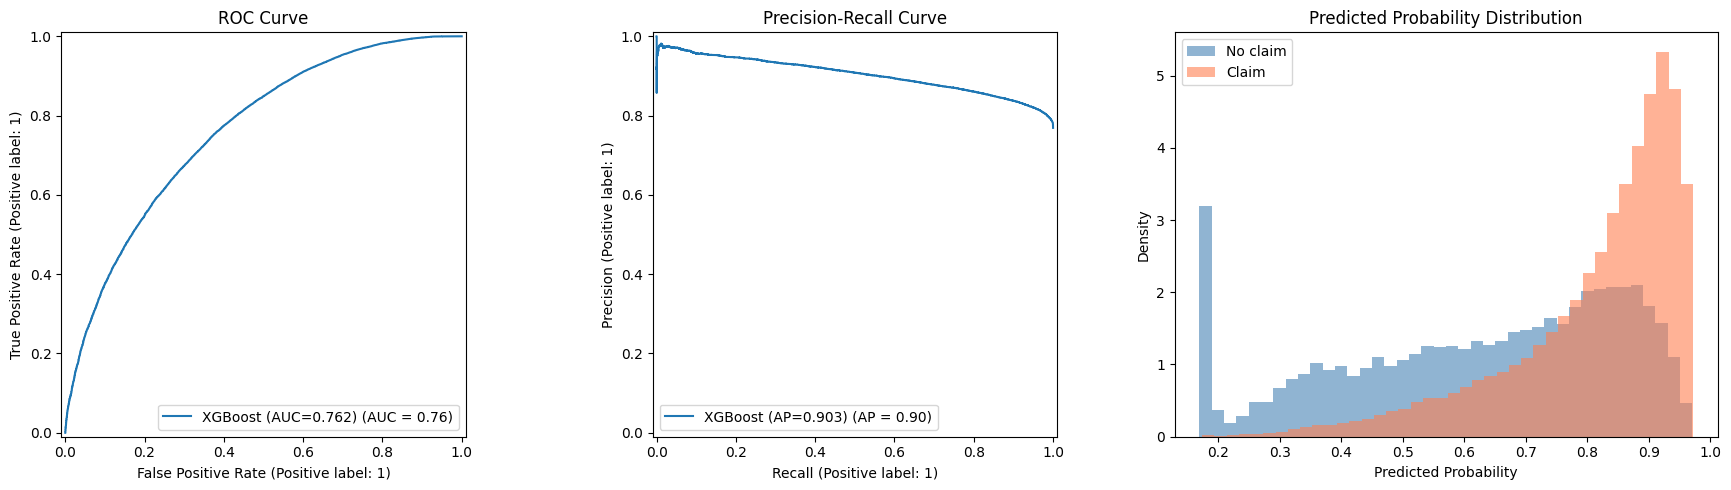


Predicted probability stats:
  mean=0.769  std=0.182
  P10=0.495  P50=0.831  P90=0.940


In [5]:
metrics = freq_model.evaluate(X_test, y_test)

print('Test Set Performance:')
print(f"  AUC-ROC:           {metrics['auc']:.4f}")
print(f"  Average Precision: {metrics['avg_precision']:.4f}")
print(f"  Brier Score:       {metrics['brier_score']:.4f}  (lower = better calibration)")
print(f"  Log Loss:          {metrics['log_loss']:.4f}")
print(f"  Test positive rate:{metrics['positive_rate']:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve
probs = freq_model.predict_proba(X_test)
RocCurveDisplay.from_predictions(y_test, probs, ax=axes[0],
                                  name=f'XGBoost (AUC={metrics["auc"]:.3f})')
axes[0].set_title('ROC Curve', fontsize=12)

# Precision-Recall curve  
PrecisionRecallDisplay.from_predictions(y_test, probs, ax=axes[1],
                                         name=f'XGBoost (AP={metrics["avg_precision"]:.3f})')
axes[1].set_title('Precision-Recall Curve', fontsize=12)

# Predicted probability distribution
axes[2].hist(probs[y_test == 0], bins=40, alpha=0.6, color='steelblue', label='No claim', density=True)
axes[2].hist(probs[y_test == 1], bins=40, alpha=0.6, color='coral', label='Claim', density=True)
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Density')
axes[2].set_title('Predicted Probability Distribution', fontsize=12)
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/fig_05_frequency_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Print probability distribution stats
print(f'\nPredicted probability stats:')
print(f'  mean={probs.mean():.3f}  std={probs.std():.3f}')
print(f'  P10={np.percentile(probs,10):.3f}  P50={np.percentile(probs,50):.3f}  P90={np.percentile(probs,90):.3f}')

## 5. Calibration Check

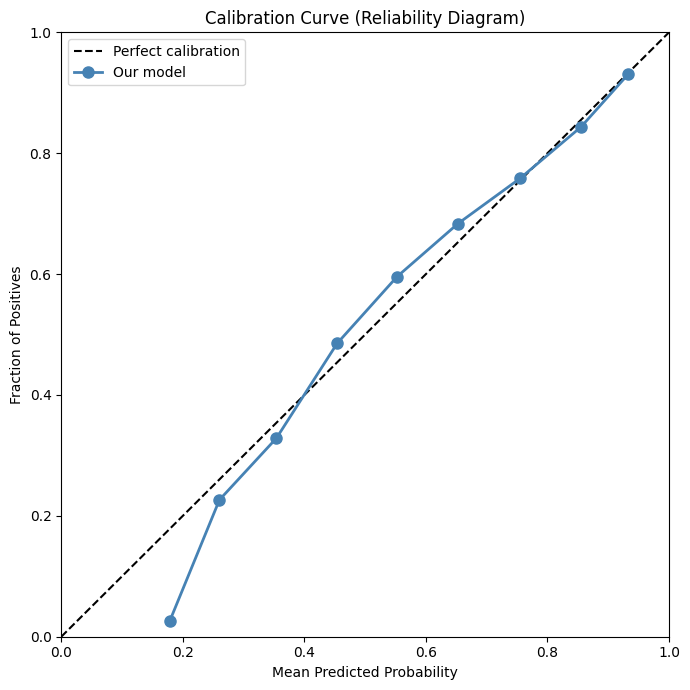

Calibration table (predicted vs actual):
 mean_predicted_prob  fraction_of_positives     gap
              0.1786                 0.0263 -0.1523
              0.2603                 0.2265 -0.0338
              0.3540                 0.3284 -0.0255
              0.4540                 0.4854  0.0314
              0.5525                 0.5958  0.0432
              0.6526                 0.6834  0.0308
              0.7547                 0.7582  0.0035
              0.8552                 0.8435 -0.0117
              0.9326                 0.9305 -0.0021

Mean |gap|: 0.0372

Good calibration = predicted probabilities match actual observed frequencies.
This is critical: the RATE in our ELT must be a reliable frequency estimate.


In [6]:
cal_data = freq_model.calibration_data(X_test, y_test, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(cal_data['mean_predicted_prob'], cal_data['fraction_of_positives'],
        'o-', color='steelblue', linewidth=2, markersize=8, label='Our model')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve (Reliability Diagram)', fontsize=12)
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../data/fig_05_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

# Print calibration table
print('Calibration table (predicted vs actual):')
cal_data['gap'] = cal_data['fraction_of_positives'] - cal_data['mean_predicted_prob']
print(cal_data.round(4).to_string(index=False))
print(f'\nMean |gap|: {cal_data["gap"].abs().mean():.4f}')
print('\nGood calibration = predicted probabilities match actual observed frequencies.')
print('This is critical: the RATE in our ELT must be a reliable frequency estimate.')

## 6. Feature Importance (SHAP)

Top 10 features by SHAP importance (frequency model):
               feature  mean_abs_shap
              latitude       0.317678
             longitude       0.263253
 log_building_coverage       0.201022
        is_flood_peril       0.169181
 flood_zone_risk_score       0.145819
          is_post_firm       0.131902
construction_age_years       0.131655
 log_contents_coverage       0.106292
    is_hurricane_peril       0.097008
  hurricane_risk_score       0.056738


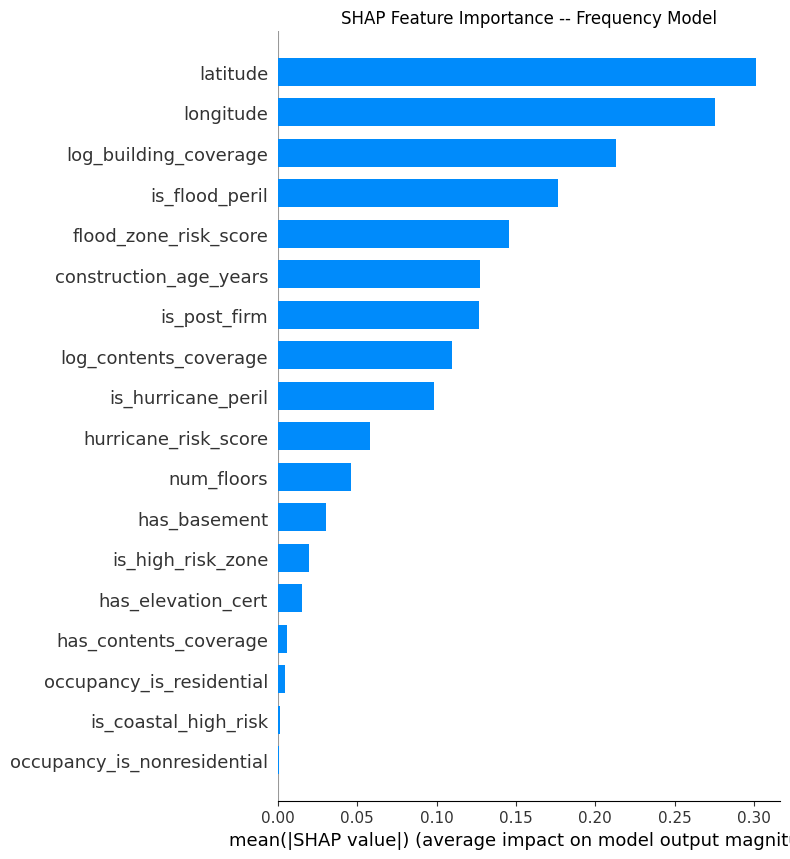

In [7]:
try:
    import shap
    shap_summary = freq_model.shap_summary(X_test, max_samples=500)
    print('Top 10 features by SHAP importance (frequency model):')
    print(shap_summary.head(10).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 6))
    explainer = shap.TreeExplainer(freq_model._model)
    X_sample = freq_model._align_features(X_test.sample(300, random_state=42))
    shap_vals = explainer.shap_values(X_sample)
    shap.summary_plot(shap_vals, X_sample, plot_type='bar', show=False)
    plt.title('SHAP Feature Importance -- Frequency Model', fontsize=12)
    plt.tight_layout()
    plt.savefig('../data/fig_05_shap_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print('shap not installed. XGBoost importances:')
    print(freq_model.feature_importances.head(10).to_string())

## 7. Save Model

In [8]:
model_path = MODEL_DIR / 'frequency_model.joblib'
freq_model.save(str(model_path))
print(f'Frequency model saved to {model_path}')
print(f'Baseline claim-paid rate: {freq_model.baseline_rate:.1%}')
print(f'Features used: {len(freq_model._feature_names)} (FREQUENCY_FEATURES)')
print('\nDone -- proceed to 06_elt_generation.ipynb')

INFO: Frequency model saved to ..\models\frequency_model.joblib


Frequency model saved to ..\models\frequency_model.joblib
Baseline claim-paid rate: 76.9%
Features used: 18 (FREQUENCY_FEATURES)

Done -- proceed to 06_elt_generation.ipynb
